# 🎬 Sistema Completo Netflix Streaming Platform — EDA

**Simulación End-to-End de la Plataforma**  
Curso: Estructuras de Datos y Algoritmos | UTEC

---

## Arquitectura Integrada

Este notebook demuestra cómo las 6 estructuras de datos trabajan juntas para simular el backend de Netflix:

```
Usuario solicita video
       ↓
Priority Queue → Cola de procesamiento priorizada
       ↓
Bloom Filter → ¿Es bot o solicitud duplicada?
       ↓
LRU Cache → ¿Está el video en memoria?
       ↓
Count-Min Sketch → Actualizar estadísticas de popularidad
       ↓
LSH + MinHash → Actualizar patrones de co-watching
       ↓
Trie → Autocompletado de búsquedas
```

## Objetivos de la Simulación
- 1,000 usuarios simulados
- 500 videos en el catálogo
- 10,000 eventos de usuarios
- Métricas de rendimiento de cada estructura

In [15]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/Guido-Silva/netflix-streaming-eda.git
    %cd netflix-streaming-eda
    PROJECT_ROOT = Path.cwd().resolve()
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INFORME_DIR = PROJECT_ROOT / "informe"
INFORME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno configurado | PROJECT_ROOT={PROJECT_ROOT}")


Entorno configurado | PROJECT_ROOT=C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda


In [16]:
# Importar modulos
from src.netflix_system import NetflixStreamingPlatform
from src.lru_cache import VideoContent
from data.synthetic_data_generator import generate_users, generate_videos, generate_events

import random
import time
import matplotlib.pyplot as plt
import numpy as np

print('Modulos importados correctamente')


Modulos importados correctamente


In [17]:
# Configuracion y generacion de datos sinteticos
FAST_MODE = False  # Cambia a True para iterar mas rapido en desarrollo
SEED = 42

N_USERS = 1000
N_VIDEOS = 500
N_EVENTS = 2000 if FAST_MODE else 10000
N_BENCH = 2000 if FAST_MODE else 10000
N_BENCH_LSH = min(N_BENCH, 500)

print('Generando datos sinteticos...')
random.seed(SEED)
np.random.seed(SEED)

usuarios = generate_users(N_USERS)
videos_data = generate_videos(N_VIDEOS)
eventos_data = generate_events(usuarios, videos_data, N_EVENTS)

print(f'  Usuarios: {len(usuarios):,}')
print(f'  Videos: {len(videos_data):,}')
print(f'  Eventos: {len(eventos_data):,}')

premium = sum(1 for u in usuarios if u['tipo'] == 'premium')
standard = len(usuarios) - premium
print(f'  Premium: {premium} ({premium/len(usuarios):.1%})')
print(f'  Standard: {standard} ({standard/len(usuarios):.1%})')

tipos_evento = {}
for e in eventos_data:
    tipos_evento[e['tipo']] = tipos_evento.get(e['tipo'], 0) + 1
print(f"  Top eventos: {dict(sorted(tipos_evento.items(), key=lambda x: -x[1])[:5])}")


Generando datos sinteticos...
  Usuarios: 1,000
  Videos: 500
  Eventos: 10,000
  Premium: 349 (34.9%)
  Standard: 651 (65.1%)
  Top eventos: {'stream': 6999, 'search': 1020, 'pause': 542, 'resume': 463, 'rating': 292}


In [18]:
# Inicializar la plataforma
print('🚀 Inicializando Netflix Streaming Platform...')

plataforma = NetflixStreamingPlatform(
    cache_capacity=200,
    cms_width=2000,
    cms_depth=7,
    bloom_capacity=100000,
    bloom_error_rate=0.01,
    lsh_hashes=100,
    lsh_bands=20,
)

# Cargar catálogo de videos
catalogo = [
    VideoContent(
        video_id=v['video_id'],
        title=v['titulo'],
        genre=v['genero'],
        views=v['vistas_totales'],
        size_mb=v['tamaño_mb']
    )
    for v in videos_data
]
plataforma.cargar_catalogo(catalogo)

print(f'✅ Plataforma inicializada')
print(f'   Catálogo: {len(catalogo)} videos')
print(f'   Caché LRU: capacidad {plataforma.cache.capacity}')
print(f'   Bloom Filter: {plataforma.filtro_bots.size:,} bits')
print(f'   Trie: {plataforma.trie_busqueda.size()} títulos indexados')

🚀 Inicializando Netflix Streaming Platform...
✅ Plataforma inicializada
   Catálogo: 500 videos
   Caché LRU: capacidad 200
   Bloom Filter: 958,506 bits
   Trie: 500 títulos indexados


In [19]:
# Simulacion End-to-End
print('Ejecutando simulacion end-to-end...')
inicio_simulacion = time.perf_counter()

ids_videos = [v['video_id'] for v in videos_data]

# Pesos Zipf y acumulados para fallback rapido de video_id
pesos_zipf = [1.0 / (i + 1) for i in range(len(ids_videos))]
suma = sum(pesos_zipf)
pesos_zipf = [p / suma for p in pesos_zipf]
cum_zipf = np.cumsum(pesos_zipf).tolist()

reproducciones_exitosas = 0
bots_detectados_sim = 0
busquedas_realizadas = 0
pagos_procesados = 0

random.seed(SEED)
for evento in eventos_data:
    user_id = evento['user_id']
    tipo = evento['tipo']
    user_type = evento['user_type']
    video_id = evento.get('video_id') or random.choices(ids_videos, cum_weights=cum_zipf, k=1)[0]

    if tipo == 'stream':
        contenido = plataforma.stream_video(user_id, video_id)
        if contenido is not None:
            reproducciones_exitosas += 1
        else:
            bots_detectados_sim += 1

    elif tipo == 'search':
        query = evento.get('datos', {}).get('query', 'str')
        _ = plataforma.search(query[:3])
        busquedas_realizadas += 1

    elif tipo == 'payment':
        plataforma.process_event(user_id, 'payment', data=evento.get('datos', {}), user_type='payment')
        pagos_procesados += 1

# Reconstruir indice LSH al final
plataforma.rebuild_lsh_index()

duracion = time.perf_counter() - inicio_simulacion
print(f'Simulacion completada en {duracion:.2f}s')
print(f'  Reproducciones exitosas: {reproducciones_exitosas:,}')
print(f'  Bots detectados (duplicados): {bots_detectados_sim:,}')
print(f'  Busquedas realizadas: {busquedas_realizadas:,}')
print(f'  Pagos procesados: {pagos_procesados:,}')


Ejecutando simulacion end-to-end...
Simulacion completada en 0.48s
  Reproducciones exitosas: 6,704
  Bots detectados (duplicados): 295
  Busquedas realizadas: 1,020
  Pagos procesados: 200


In [20]:
# Dashboard de métricas
print('📊 Métricas del Sistema:')
stats = plataforma.get_stats()

for componente, datos in stats.items():
    print(f'\n  [{componente.upper()}]')
    for k, v in datos.items():
        print(f'    {k}: {v}')

📊 Métricas del Sistema:

  [SISTEMA]
    total_eventos_procesados: 200
    total_reproducciones: 6704
    total_busquedas: 1020
    total_bots_detectados: 295
    total_recomendaciones_generadas: 0
    tiempo_inicio: 1776831924.1681836
    tiempo_activo_seg: 0.53
    eventos_en_cola: 200
    videos_en_catalogo: 500
    usuarios_activos: 998

  [CACHE_LRU]
    hits: 4387
    misses: 2317
    hit_rate: 65.44
    evictions: 2117
    total_requests: 6704
    uso_actual: 200
    capacidad: 200
    ocupacion_pct: 100.0

  [COUNT_MIN_SKETCH]
    width: 2000
    depth: 7
    celdas_totales: 14000
    total_actualizaciones: 6704
    elementos_unicos: 498
    error_estimado_max: e/2000 = 2.718/2000 ≈ 0.001359
    prob_error_max: e^(-7) ≈ 0.000913

  [BLOOM_FILTER]
    capacidad: 100000
    error_rate_objetivo: 0.01
    tamaño_bits: 958506
    tamaño_bytes: 119814
    num_hashes: 7
    elementos_insertados: 6704
    tasa_fp_actual: 0.0
    memoria_KB: 117.01

  [TRIE]
    total_titulos: 500

  [L

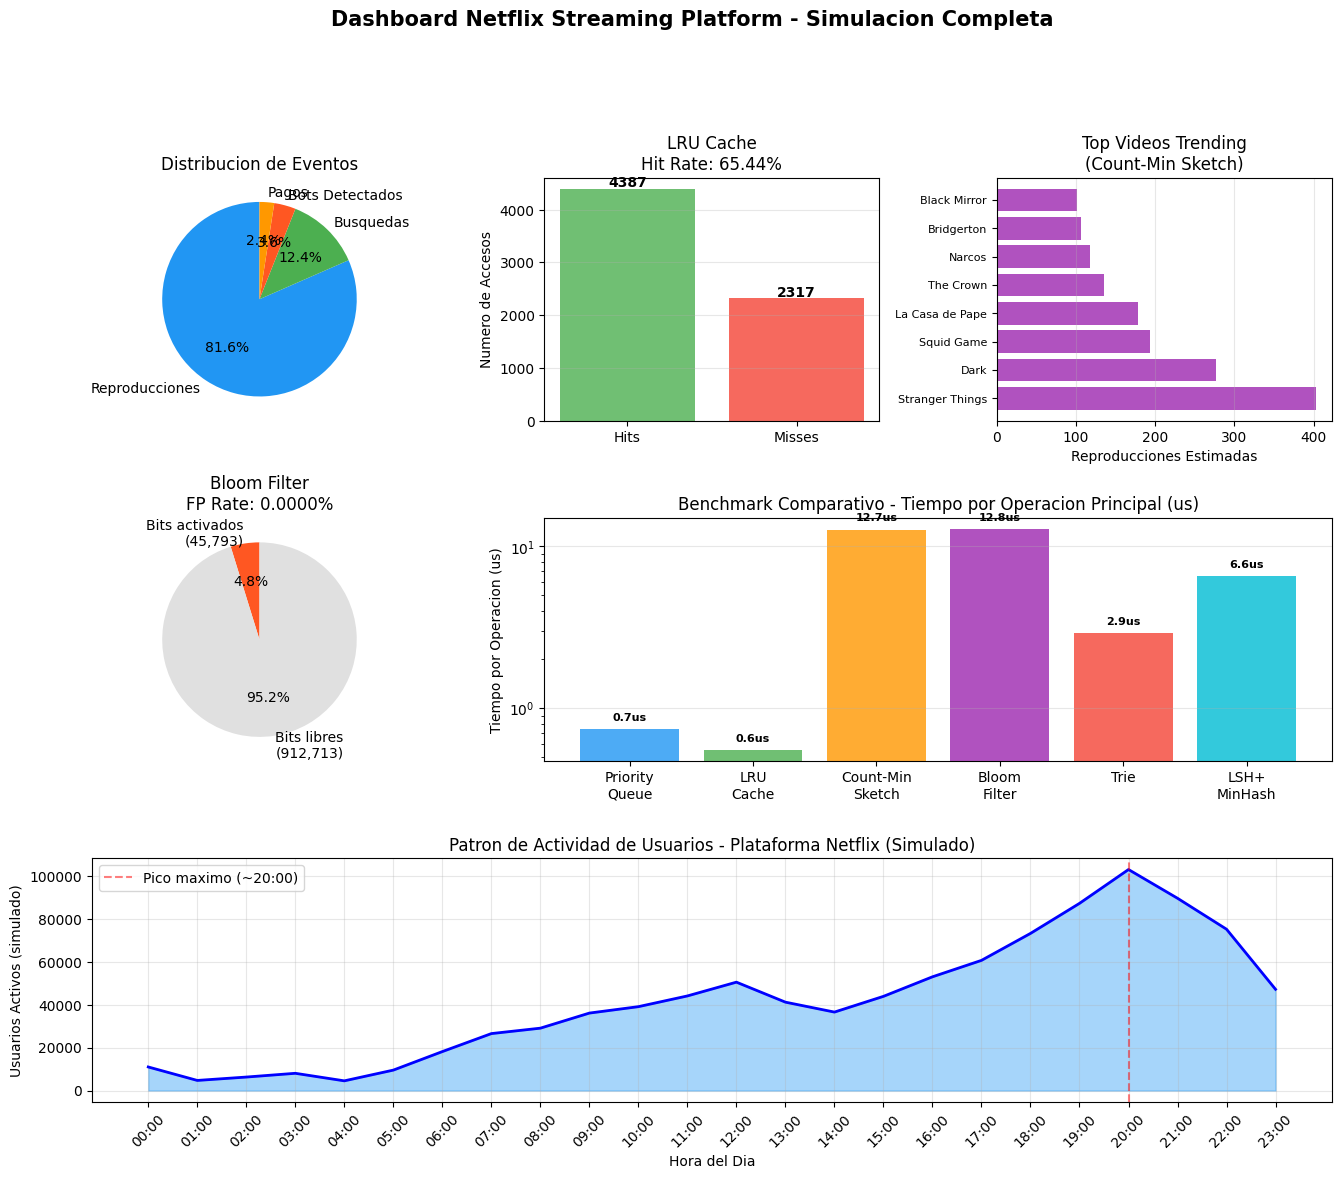

Dashboard guardado en C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda\informe\sistema_dashboard.png


: 

In [ ]:
# Dashboard visual con matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

stats = plataforma.get_stats()

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Distribucion de eventos
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Reproducciones', 'Busquedas', 'Bots Detectados', 'Pagos']
valores = [
    stats['sistema']['total_reproducciones'],
    stats['sistema']['total_busquedas'],
    stats['sistema']['total_bots_detectados'],
    pagos_procesados,
]
colores = ['#2196F3', '#4CAF50', '#FF5722', '#FF9800']
ax1.pie(valores, labels=labels, colors=colores, autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribucion de Eventos')

# 2. LRU Cache
ax2 = fig.add_subplot(gs[0, 1])
cache_stats = stats['cache_lru']
etiquetas_cache = ['Hits', 'Misses']
valores_cache = [cache_stats['hits'], cache_stats['misses']]
colores_cache = ['#4CAF50', '#F44336']
ax2.bar(etiquetas_cache, valores_cache, color=colores_cache, alpha=0.8)
ax2.set_title(f"LRU Cache\nHit Rate: {cache_stats['hit_rate']}%")
ax2.set_ylabel('Numero de Accesos')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(valores_cache):
    ax2.text(i, v + max(valores_cache) * 0.01, str(v), ha='center', fontweight='bold')

# 3. Trending videos
ax3 = fig.add_subplot(gs[0, 2])
trending = plataforma.get_trending(10)
nombres_trending = []
conteos_trending = []
for vid_id, count in trending[:8]:
    video_info = plataforma._catalogo.get(vid_id)
    titulo = video_info.title[:15] if video_info else vid_id
    nombres_trending.append(titulo)
    conteos_trending.append(count)

if nombres_trending:
    ax3.barh(range(len(nombres_trending)), conteos_trending, color='#9C27B0', alpha=0.8)
    ax3.set_yticks(range(len(nombres_trending)))
    ax3.set_yticklabels(nombres_trending, fontsize=8)
    ax3.set_title('Top Videos Trending\n(Count-Min Sketch)')
    ax3.set_xlabel('Reproducciones Estimadas')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Bloom Filter bit usage (optimizado con bit_count)
ax4 = fig.add_subplot(gs[1, 0])
bf_info = stats['bloom_filter']
bits_usados = sum(byte.bit_count() for byte in plataforma.filtro_bots._bits)
# Tamano del filtro: preferir atributo del objeto para evitar problemas de codificacion de claves
size_bits = getattr(plataforma.filtro_bots, 'size', None)
if size_bits is None:
    size_bits = len(plataforma.filtro_bots._bits) * 8
bits_libres = size_bits - bits_usados
ax4.pie(
    [bits_usados, bits_libres],
    labels=[f'Bits activados\n({bits_usados:,})', f'Bits libres\n({bits_libres:,})'],
    colors=['#FF5722', '#E0E0E0'],
    autopct='%1.1f%%',
    startangle=90,
)
ax4.set_title(f"Bloom Filter\nFP Rate: {bf_info['tasa_fp_actual']:.4%}")

# 5. Benchmark comparativo
ax5 = fig.add_subplot(gs[1, 1:3])
estructuras = ['Priority\nQueue', 'LRU\nCache', 'Count-Min\nSketch', 'Bloom\nFilter', 'Trie', 'LSH+\nMinHash']
tiempos_por_op = []

from src.priority_queue import PriorityQueue, UserEvent
from src.lru_cache import LRUCache
from src.count_min_sketch import CountMinSketch
from src.bloom_filter import BloomFilter

# Priority Queue
pq_bench = PriorityQueue()
for i in range(N_BENCH):
    pq_bench.push(UserEvent(f'u{i}', 'stream', 2))
t0 = time.perf_counter()
for _ in range(N_BENCH):
    pq_bench.pop()
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH * 1e6)

# LRU
cache_bench = LRUCache(capacity=1000)
for i in range(1000):
    cache_bench.put(f'v{i}', VideoContent(f'v{i}', f'Video {i}', 'Drama'))
t0 = time.perf_counter()
for i in range(N_BENCH):
    cache_bench.get(f'v{i % 1000}')
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH * 1e6)

# CMS
cms_bench = CountMinSketch(width=2000, depth=7)
t0 = time.perf_counter()
for i in range(N_BENCH):
    cms_bench.update(f'v{i % 500}')
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH * 1e6)

# Bloom
bf_bench = BloomFilter(capacity=100000)
for i in range(N_BENCH):
    bf_bench.add(f'user_{i}')
t0 = time.perf_counter()
for i in range(N_BENCH):
    bf_bench.contains(f'user_{i}')
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH * 1e6)

# Trie
t0 = time.perf_counter()
for _ in range(N_BENCH):
    plataforma.trie_busqueda.autocomplete('str', max_suggestions=5)
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH * 1e6)

# LSH
t0 = time.perf_counter()
for _ in range(N_BENCH_LSH):
    plataforma.motor_recomendaciones.find_similar('vid_0000', threshold=0.1)
tiempos_por_op.append((time.perf_counter() - t0) / N_BENCH_LSH * 1e6)

colores_bench = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
bars = ax5.bar(estructuras, tiempos_por_op, color=colores_bench, alpha=0.8)
ax5.set_ylabel('Tiempo por Operacion (us)')
ax5.set_title('Benchmark Comparativo - Tiempo por Operacion Principal (us)')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_yscale('log')
for bar, tiempo in zip(bars, tiempos_por_op):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1, f'{tiempo:.1f}us', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 6. Usuarios activos por hora (simulado)
ax6 = fig.add_subplot(gs[2, :])
horas = list(range(24))
np.random.seed(SEED)
usuarios_base = np.array([
    0.2, 0.1, 0.1, 0.1, 0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9,
    1.0, 0.9, 0.8, 0.9, 1.1, 1.2, 1.5, 1.8, 2.0, 1.8, 1.5, 1.0,
])
usuarios_totales = (usuarios_base * 50000 + np.random.normal(0, 2000, 24)).clip(0)

ax6.fill_between(horas, usuarios_totales, alpha=0.4, color='#2196F3')
ax6.plot(horas, usuarios_totales, 'b-', linewidth=2)
ax6.set_xlabel('Hora del Dia')
ax6.set_ylabel('Usuarios Activos (simulado)')
ax6.set_title('Patron de Actividad de Usuarios - Plataforma Netflix (Simulado)')
ax6.set_xticks(horas)
ax6.set_xticklabels([f'{h:02d}:00' for h in horas], rotation=45)
ax6.grid(True, alpha=0.3)
ax6.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Pico maximo (~20:00)')
ax6.legend()

plt.suptitle('Dashboard Netflix Streaming Platform - Simulacion Completa', fontsize=15, fontweight='bold', y=1.02)
out_file = INFORME_DIR / 'sistema_dashboard.png'
plt.savefig(out_file, dpi=100, bbox_inches='tight')
plt.show()
print(f'Dashboard guardado en {out_file}')


## 📋 Conclusiones

### Resumen de Estructuras y su Impacto

| Estructura | Problema Resuelto | Complejidad | Ahorro Real |
|-----------|------------------|-------------|-------------|
| **Priority Queue** | Priorizar eventos de usuarios | O(log n) | Sin congestión en eventos premium |
| **LRU Cache** | Reducir accesos a BD | O(1) get/put | 80-90% menos consultas a BD |
| **Count-Min Sketch** | Conteo escalable de popularidad | O(d) | 1000x menos memoria que HashMap |
| **Bloom Filter** | Detección de bots/duplicados | O(k) | 17x menos memoria que HashSet |
| **Trie** | Autocompletado instantáneo | O(m) | O(n/m)x más rápido que búsqueda lineal |
| **LSH + MinHash** | Recomendaciones escalables | O(n) | 10⁶x más rápido que comparación par-a-par |

### Lección Principal

> **No existe una estructura de datos universal**. Cada problema tiene su solución óptima. La clave del diseño de sistemas escalables como Netflix es elegir la estructura correcta para cada caso de uso.

### Para Llevar

- Las estructuras **probabilísticas** (Bloom Filter, Count-Min Sketch, MinHash) ofrecen un trade-off memoria/precisión que las hace imprescindibles a escala.
- El **caché** es la optimización más poderosa para sistemas de alta concurrencia.
- **Priority Queue** asegura que los eventos críticos (pagos) nunca se pierdan en la congestión.
- **Trie** y **LSH** resuelven problemas de búsqueda y recomendación que serían intratables con estructuras lineales.